# Naming sanitization
Notebook to sanitize all names for packages, rasters, etc.

## Modules

In [68]:
import pandas as pd
import geopandas as gpd
import pyogrio
import numpy as np

In [2]:
geom_layer = "geometry_layer"

In [3]:
rename_cols = {
    'cf': 'leaf', 
    'cf_median': 'leaf_median', 
    'cf_std': 'leaf_std', 
}

rename_metrics = {
    'cf_mean': 'leaf_mean', 
    'cf_median': 'leaf_median', 
    'cf_std': 'leaf_std', 
}

In [4]:
def inspect_gpkg(filepath: str):
    layer_info = pyogrio.list_layers(filepath)  # array of [name, geom_type]

    for name, geom_type in layer_info:
        if geom_type is None:
            # non-spatial table -> read without geometry
            df = gpd.read_file(filepath, layer=name, ignore_geometry=True)
            print(f"{name}: TABLE, shape={df.shape}, columns={list(df.columns)}")
        else:
            gdf = gpd.read_file(filepath, layer=name)
            print(f"{name}: {gdf.shape}, CRS={gdf.crs}, geom={gdf.geom_type.unique()}, geom_type_reported={geom_type}")

In [5]:
def load_gpkg(filepath: str):
    layer_info = pyogrio.list_layers(filepath)
    
    data = {}
    
    for name, geom_type in layer_info:
        if geom_type is None:
            df = gpd.read_file(filepath, layer=name, ignore_geometry=True)
        else:
            df = gpd.read_file(filepath, layer=name)
        data[name] = df
    
    return data

In [6]:
def update_gpkg_to_disk(data: gpd.GeoDataFrame, gpkg_path: str):
    first = True
    for name, df in data.items():
        mode = "w" if first else "a"
        if isinstance(df, gpd.GeoDataFrame):
            df.to_file(gpkg_path, layer=name, driver="GPKG", mode=mode)
        else:
            # non-spatial table: needs pyogrio directly since to_file expects geometry
            pyogrio.write_dataframe(df, gpkg_path, layer=name, driver="GPKG", append=(mode == "a"))
        first = False

    print(f'Geopackage updated into: {gpkg_path}')

## Acidification

### Ecoregion

In [50]:
acid_er_fp = "../LEAFs/acidification/acidification_ecoregion.gpkg"
acid_er_df_fp = "../LEAFs/acidification/acidification_ecoregion.csv"

In [51]:
inspect_gpkg(acid_er_fp)

geometry_layer: (829, 8), CRS=EPSG:6933, geom=['MultiPolygon'], geom_type_reported=MultiPolygon
acid_leaf_ecoregions: TABLE, shape=(4974, 6), columns=['ECO_ID', 'flow_name', 'cf', 'cf_median', 'cf_std', '_source_file']
acid_leaf_ecoregions_metadata: TABLE, shape=(6, 4), columns=['flow_name', 'impact_category', 'unit', 'source_file']


In [52]:
ac_er_gpkg_data = load_gpkg(acid_er_fp)

In [53]:
ac_er_gpkg_data['acid_leaf_ecoregions'] = ac_er_gpkg_data['acid_leaf_ecoregions'].rename(columns = rename_cols)

In [54]:
update_gpkg_to_disk(ac_er_gpkg_data, acid_er_fp)

Geopackage updated into: ../LEAFs/acidification/acidification_ecoregion.gpkg


#### df

In [55]:
acid_er_df = pd.read_csv(acid_er_df_fp)

In [56]:
acid_er_df.head()

,ECO_ID,flow_name,metric,value,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM
0,135,acid_nox,cf_mean,0.017107,Admiralty Islands lowland rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia
1,785,acid_nox,cf_mean,0.438687,Aegean and Western Turkey sclerophyllous and m...,12.0,"Mediterranean Forests, Woodlands & Scrub",Palearctic
2,807,acid_nox,cf_mean,1.092774,Afghan Mountains semi-desert,13.0,Deserts & Xeric Shrublands,Palearctic
3,404,acid_nox,cf_mean,0.351993,Ahklun and Kilbuck Upland Tundra,11.0,Tundra,Nearctic
4,722,acid_nox,cf_mean,0.409728,Al-Hajar foothill xeric woodlands and shrublands,8.0,"Temperate Grasslands, Savannas & Shrublands",Palearctic


In [57]:
acid_er_df["metric"] = acid_er_df["metric"].replace(rename_metrics)

In [58]:
acid_er_df["metric"].unique()

array(['leaf_mean', 'leaf_median', 'leaf_std'], dtype=object)

In [59]:
acid_er_df.to_csv(acid_er_df_fp, index=False)

In [60]:
pd.read_csv(acid_er_df_fp).head()

,ECO_ID,flow_name,metric,value,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM
0,135,acid_nox,leaf_mean,0.017107,Admiralty Islands lowland rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia
1,785,acid_nox,leaf_mean,0.438687,Aegean and Western Turkey sclerophyllous and m...,12.0,"Mediterranean Forests, Woodlands & Scrub",Palearctic
2,807,acid_nox,leaf_mean,1.092774,Afghan Mountains semi-desert,13.0,Deserts & Xeric Shrublands,Palearctic
3,404,acid_nox,leaf_mean,0.351993,Ahklun and Kilbuck Upland Tundra,11.0,Tundra,Nearctic
4,722,acid_nox,leaf_mean,0.409728,Al-Hajar foothill xeric woodlands and shrublands,8.0,"Temperate Grasslands, Savannas & Shrublands",Palearctic


### Subcountries

In [77]:
acid_sc_fp = "../LEAFs/acidification/acidification_subcountry.gpkg"
acid_sc_df_fp = "../LEAFs/acidification/acidification_subcountry.csv"

In [78]:
inspect_gpkg(acid_sc_fp)

geometry_layer: (3422, 4), CRS=EPSG:6933, geom=['MultiPolygon'], geom_type_reported=MultiPolygon
acid_leaf_subcountry: TABLE, shape=(20532, 6), columns=['ADM1_CODE', 'flow_name', 'cf', 'cf_median', 'cf_std', '_source_file']
acid_leaf_subcountry_metadata: TABLE, shape=(6, 4), columns=['flow_name', 'impact_category', 'unit', 'source_file']


In [79]:
ac_sc_gpkg_data = load_gpkg(acid_sc_fp)

In [81]:
ac_sc_gpkg_data['acid_leaf_subcountry'] = ac_sc_gpkg_data['acid_leaf_subcountry'].rename(columns = rename_cols)

In [83]:
ac_sc_gpkg_data['acid_leaf_subcountry'].head()

,ADM1_CODE,flow_name,leaf,leaf_median,leaf_std,_source_file
0,40542,acid_nh3,0.818360,0.794068,6.332038e-02,acid_nh3.tif
1,40543,acid_nh3,0.794068,0.794068,1.110223e-16,acid_nh3.tif
2,40544,acid_nh3,0.794068,0.794068,1.110223e-16,acid_nh3.tif
3,40545,acid_nh3,0.794068,0.794068,1.110223e-16,acid_nh3.tif
4,40546,acid_nh3,1.038711,1.032421,1.680182e-02,acid_nh3.tif


In [82]:
update_gpkg_to_disk(ac_sc_gpkg_data, acid_sc_fp)

Geopackage updated into: ../LEAFs/acidification/acidification_subcountry.gpkg


#### df

In [69]:
acid_sc_df = pd.read_csv(acid_sc_df_fp)

In [70]:
acid_sc_df.head()

,ADM0_NAME,ADM1_NAME,ADM1_CODE,flow_name,metric,value
0,Burundi,Bubanza,40542,acid_nh3,leaf_mean,0.818360
1,Burundi,Bujumbura Mairie,40543,acid_nh3,leaf_mean,0.794068
2,Burundi,Bujumbura Rural,40544,acid_nh3,leaf_mean,0.794068
3,Burundi,Bururi,40545,acid_nh3,leaf_mean,0.794068
4,Burundi,Cankuzo,40546,acid_nh3,leaf_mean,1.038711


In [71]:
acid_sc_df["metric"] = acid_sc_df["metric"].replace(rename_metrics)

In [72]:
acid_sc_df["metric"].unique()

array(['leaf_mean', 'leaf_median', 'leaf_std'], dtype=object)

In [73]:
acid_sc_df.to_csv(acid_sc_df_fp, index=False)

In [74]:
pd.read_csv(acid_sc_df_fp).head()

,ADM0_NAME,ADM1_NAME,ADM1_CODE,flow_name,metric,value
0,Burundi,Bubanza,40542,acid_nh3,leaf_mean,0.818360
1,Burundi,Bujumbura Mairie,40543,acid_nh3,leaf_mean,0.794068
2,Burundi,Bujumbura Rural,40544,acid_nh3,leaf_mean,0.794068
3,Burundi,Bururi,40545,acid_nh3,leaf_mean,0.794068
4,Burundi,Cankuzo,40546,acid_nh3,leaf_mean,1.038711


### Countries

In [84]:
acid_c_fp = "../LEAFs/acidification/acidification_country.gpkg"
acid_c_df_fp = "../LEAFs/acidification/acidification_country.csv"

In [85]:
inspect_gpkg(acid_c_fp)

geometry_layer: (276, 2), CRS=EPSG:6933, geom=['MultiPolygon'], geom_type_reported=MultiPolygon
acid_leaf_country: TABLE, shape=(828, 6), columns=['ADM0_NAME', 'flow_name', 'cf', 'cf_median', 'cf_std', '_source_file']
acid_leaf_country_metadata: TABLE, shape=(3, 4), columns=['flow_name', 'impact_category', 'unit', 'source_file']


In [86]:
ac_c_gpkg_data = load_gpkg(acid_c_fp)

In [87]:
ac_c_gpkg_data['acid_leaf_country'] = ac_c_gpkg_data['acid_leaf_country'].rename(columns = rename_cols)

In [95]:
ac_c_gpkg_data['acid_leaf_country'].head()

,ADM0_NAME,flow_name,leaf,leaf_median,leaf_std,_source_file
0,Abyei,SO2,1.114701,1.114701,2.220446e-16,acid_so2.tif
1,Afghanistan,SO2,2.585822,2.334591,8.948115e-01,acid_so2.tif
2,Aksai Chin,SO2,3.324237,3.453164,5.836048e-01,acid_so2.tif
3,Albania,SO2,1.269199,1.258024,5.401168e-01,acid_so2.tif
4,Algeria,SO2,0.600109,0.583725,1.501198e-01,acid_so2.tif


In [88]:
update_gpkg_to_disk(ac_c_gpkg_data, acid_c_fp)

Geopackage updated into: ../LEAFs/acidification/acidification_country.gpkg


#### df

In [89]:
acid_c_df = pd.read_csv(acid_c_df_fp)

In [90]:
acid_c_df.head()

,ADM0_NAME,flow_name,metric,value
0,Abyei,acid_so2,cf_mean,1.114701
1,Afghanistan,acid_so2,cf_mean,2.585822
2,Aksai Chin,acid_so2,cf_mean,3.324237
3,Albania,acid_so2,cf_mean,1.269199
4,Algeria,acid_so2,cf_mean,0.600109


In [91]:
acid_c_df["metric"] = acid_c_df["metric"].replace(rename_metrics)

In [92]:
acid_c_df["metric"].unique()

array(['leaf_mean', 'leaf_median', 'leaf_std'], dtype=object)

In [93]:
acid_c_df.to_csv(acid_c_df_fp, index=False)

In [94]:
pd.read_csv(acid_c_df_fp).head()

,ADM0_NAME,flow_name,metric,value
0,Abyei,acid_so2,leaf_mean,1.114701
1,Afghanistan,acid_so2,leaf_mean,2.585822
2,Aksai Chin,acid_so2,leaf_mean,3.324237
3,Albania,acid_so2,leaf_mean,1.269199
4,Algeria,acid_so2,leaf_mean,0.600109


## Soil Erosion

#### Ecoregions

In [57]:
soil_er_fp = "../LEAFs/soil_erosion/se_ecoregions_clipped_2.gpkg"
soil_er_df_fp = "../LEAFs/soil_erosion/se_ecoregions_clipped_2.csv"

In [58]:
inspect_gpkg(soil_er_fp)

geometry_layer: (847, 8), CRS=EPSG:6933, geom=['MultiPolygon'], geom_type_reported=MultiPolygon
se_leaf_ecoregions: TABLE, shape=(84376, 6), columns=['ECO_ID', 'flow_name', 'leaf', 'leaf_median', 'leaf_std', '_source_file']
se_leaf_ecoregions_metadata: TABLE, shape=(106, 4), columns=['flow_name', 'impact_category', 'unit', 'source_file']


In [59]:
se_er_gpkg_data = load_gpkg(soil_er_fp)

In [60]:
se_er_gpkg_data['se_leaf_ecoregions'] = se_er_gpkg_data['se_leaf_ecoregions'].rename(columns = rename_cols)

In [61]:
se_er_gpkg_data['se_leaf_ecoregions'].head()

,ECO_ID,flow_name,leaf,leaf_median,leaf_std,_source_file
0,135,Barley_rf_ron_rt,NaN,NaN,NaN,se_rate_25km_clipped_Barley_rf_ron_rt.tif
1,785,Barley_rf_ron_rt,5.387818,3.910269,4.863152,se_rate_25km_clipped_Barley_rf_ron_rt.tif
2,807,Barley_rf_ron_rt,2.773447,1.799929,4.479747,se_rate_25km_clipped_Barley_rf_ron_rt.tif
3,722,Barley_rf_ron_rt,NaN,NaN,NaN,se_rate_25km_clipped_Barley_rf_ron_rt.tif
4,723,Barley_rf_ron_rt,NaN,NaN,NaN,se_rate_25km_clipped_Barley_rf_ron_rt.tif


Plotting to see there are no antarctica neither tundra values

In [ ]:
se_er =se_er_gpkg_data[geom_layer].merge(se_er_gpkg_data['se_leaf_ecoregions'], how="left", on = "ECO_ID")

<Axes: >

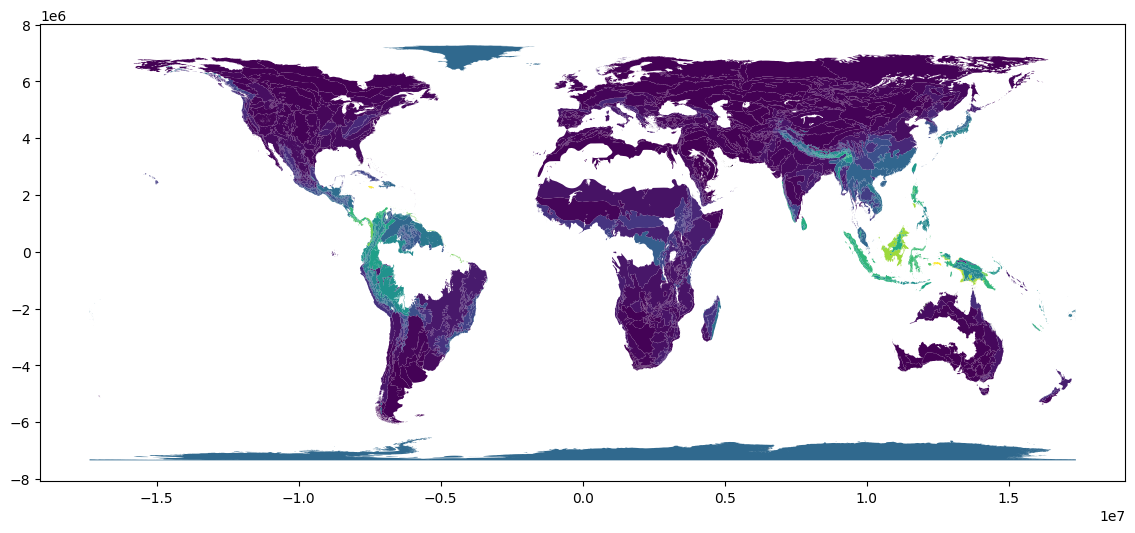

In [64]:
se_er[se_er["flow_name"]=="Barley_rf_ron_rt"].plot(column = "leaf", figsize = (14,8))

So it does have... After 1,000 times deleting them they still have it...

In [96]:
tundra_codes = se_er[se_er["BIOME_NAME"] == "Tundra"]["ECO_ID"]

In [97]:
tundra_codes

0        117
319      404
744      405
1275     406
2866     196
3715     407
3716     778
3717     408
6368     779
6369     409
6370     410
7537     411
8704     413
14323    118
15278    771
16339    772
19414    415
20475    120
24080    121
24081    122
24188    123
30337    412
33200    416
35215    418
37124    774
43379    414
48150    126
48151    127
48788    125
49213    775
52182    776
52713    777
53244    419
54093    420
56850    128
61197    780
61198    129
64061    130
64910    131
65229    132
67456    133
71485    781
74242    421
74243    782
74562    134
79545    783
79758    784
82939    773
83046    417
83895    119
83896    124
Name: ECO_ID, dtype: int64

In [98]:
data = se_er_gpkg_data['se_leaf_ecoregions']

In [99]:
data.head()

,ECO_ID,flow_name,leaf,leaf_median,leaf_std,_source_file
0,135,Barley_rf_ron_rt,NaN,NaN,NaN,se_rate_25km_clipped_Barley_rf_ron_rt.tif
1,785,Barley_rf_ron_rt,5.387818,3.910269,4.863152,se_rate_25km_clipped_Barley_rf_ron_rt.tif
2,807,Barley_rf_ron_rt,2.773447,1.799929,4.479747,se_rate_25km_clipped_Barley_rf_ron_rt.tif
3,722,Barley_rf_ron_rt,NaN,NaN,NaN,se_rate_25km_clipped_Barley_rf_ron_rt.tif
4,723,Barley_rf_ron_rt,NaN,NaN,NaN,se_rate_25km_clipped_Barley_rf_ron_rt.tif


In [100]:
data.loc[data["ECO_ID"].isin(tundra_codes), ["leaf", "leaf_median", "leaf_std"]] = np.nan

In [101]:
se_er_gpkg_data['se_leaf_ecoregions'] = data

In [102]:
se_er =se_er_gpkg_data[geom_layer].merge(se_er_gpkg_data['se_leaf_ecoregions'], how="left", on = "ECO_ID")

In [103]:
se_er[(se_er["BIOME_NAME"]=="Tundra")]["leaf"].unique()

array([nan])

<Axes: >

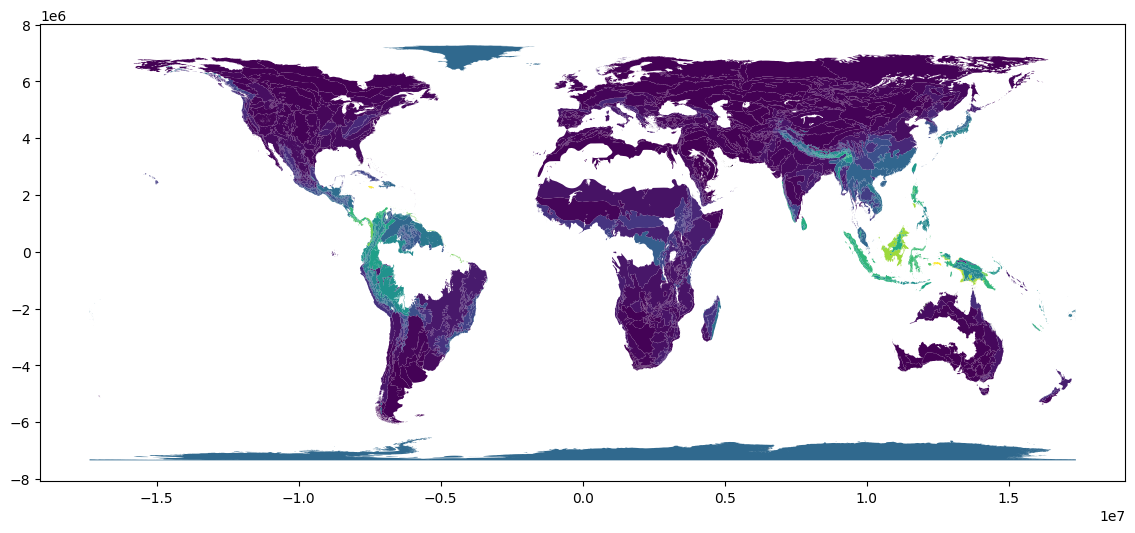

In [104]:
se_er[se_er["flow_name"]=="Barley_rf_ron_rt"].plot(column = "leaf", figsize = (14,8))

##### Saving

In [101]:
update_gpkg_to_disk(se_er_gpkg_data, soil_er_fp)

Geopackage updated into: ../LEAFs/soil_erosion/soil_erosion_country.gpkg


#### df

In [102]:
soil_er_df = pd.read_csv(soil_er_df_fp)

In [103]:
soil_er_df.head()

,Unnamed: 0,BIOME_NAME,ECO_NAME,ECO_ID,flow_name,leaf,leaf_median,leaf_std,_source_file
0,0,Tropical & Subtropical Moist Broadleaf Forests,Admiralty Islands lowland rain forests,135,Barley_irr_ron_rt,21.762239,22.782883,4.215090,se_rate_25km_clipped_Barley_irr_ron_rt.tif
1,1,"Mediterranean Forests, Woodlands & Scrub",Aegean and Western Turkey sclerophyllous and m...,785,Barley_irr_ron_rt,5.545331,4.050676,4.997880,se_rate_25km_clipped_Barley_irr_ron_rt.tif
2,2,Deserts & Xeric Shrublands,Afghan Mountains semi-desert,807,Barley_irr_ron_rt,7.512600,2.799777,10.390734,se_rate_25km_clipped_Barley_irr_ron_rt.tif
3,3,"Temperate Grasslands, Savannas & Shrublands",Al-Hajar foothill xeric woodlands and shrublands,722,Barley_irr_ron_rt,3.608916,4.417599,2.729809,se_rate_25km_clipped_Barley_irr_ron_rt.tif
4,4,"Temperate Grasslands, Savannas & Shrublands",Al-Hajar montane woodlands and shrublands,723,Barley_irr_ron_rt,4.911119,4.417599,2.022715,se_rate_25km_clipped_Barley_irr_ron_rt.tif


Already in a good spot. No need to change

#### Subcountry

In [107]:
soil_sc_fp = "../LEAFs/soil_erosion/soil_erosion_subcountry.gpkg"
soil_sc_df_fp = "../LEAFs/soil_erosion/soil_erosion_subcountry.csv"

In [108]:
inspect_gpkg(soil_sc_fp)

geometry_layer: (3422, 4), CRS=EPSG:6933, geom=['MultiPolygon'], geom_type_reported=MultiPolygon
se_leaf_subcountry: TABLE, shape=(273760, 6), columns=['ADM1_CODE', 'flow_name', 'cf', 'cf_median', 'cf_std', '_source_file']
se_leaf_subcountry_metadata: TABLE, shape=(80, 4), columns=['flow_name', 'impact_category', 'unit', 'source_file']


In [109]:
se_sc_gpkg_data = load_gpkg(soil_sc_fp)

In [110]:
se_sc_gpkg_data['se_leaf_subcountry'] = se_sc_gpkg_data['se_leaf_subcountry'].rename(columns = rename_cols)

In [111]:
se_sc_gpkg_data['se_leaf_subcountry'].head()

,ADM1_CODE,flow_name,leaf,leaf_median,leaf_std,_source_file
0,40542,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
1,40543,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
2,40544,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
3,40545,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
4,40546,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif


In [112]:
update_gpkg_to_disk(se_sc_gpkg_data, soil_sc_fp)

Geopackage updated into: ../LEAFs/soil_erosion/soil_erosion_subcountry.gpkg


#### df

In [113]:
soil_sc_df = pd.read_csv(soil_sc_df_fp)

In [114]:
soil_sc_df.head()

,ADM1_CODE,value,metric,flow_name,ADM1_NAME,ADM0_NAME
0,40542,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bubanza,Burundi
1,40543,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Mairie,Burundi
2,40544,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Rural,Burundi
3,40545,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bururi,Burundi
4,40546,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Cankuzo,Burundi


In [115]:
soil_sc_df["metric"] = soil_sc_df["metric"].replace(rename_metrics)

In [116]:
soil_sc_df["metric"].unique()

array(['leaf_mean', 'leaf_median', 'leaf_std'], dtype=object)

In [117]:
soil_sc_df.to_csv(soil_sc_df_fp, index=False)

In [118]:
pd.read_csv(soil_sc_df_fp).head()

,ADM1_CODE,value,metric,flow_name,ADM1_NAME,ADM0_NAME
0,40542,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bubanza,Burundi
1,40543,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Mairie,Burundi
2,40544,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Rural,Burundi
3,40545,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bururi,Burundi
4,40546,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Cankuzo,Burundi


### Country

In [119]:
soil_c_fp = "../LEAFs/soil_erosion/soil_erosion_country.gpkg"
soil_c_df_fp = "../LEAFs/soil_erosion/soil_erosion_country.csv"

In [120]:
inspect_gpkg(soil_c_fp)

geometry_layer: (276, 2), CRS=EPSG:6933, geom=['MultiPolygon'], geom_type_reported=MultiPolygon
se_leaf_country: TABLE, shape=(44160, 6), columns=['ADM0_NAME', 'flow_name', 'cf', 'cf_median', 'cf_std', '_source_file']
se_leaf_country_metadata: TABLE, shape=(160, 4), columns=['flow_name', 'impact_category', 'unit', 'source_file']


In [121]:
se_c_gpkg_data = load_gpkg(soil_c_fp)

In [122]:
se_c_gpkg_data['se_leaf_country'] = se_c_gpkg_data['se_leaf_country'].rename(columns = rename_cols)

In [123]:
se_c_gpkg_data['se_leaf_country'].head()

,ADM0_NAME,flow_name,leaf,leaf_median,leaf_std,_source_file
0,Abyei,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
1,Afghanistan,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
2,Aksai Chin,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
3,Albania,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
4,Algeria,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif


In [ ]:
update_gpkg_to_disk(se_c_gpkg_data, soil_c_fp)

Geopackage updated into: ../LEAFs/soil_erosion/soil_erosion_subcountry.gpkg


#### df

In [ ]:
soil_sc_df = pd.read_csv(soil_sc_df_fp)

In [ ]:
soil_sc_df.head()

,ADM1_CODE,value,metric,flow_name,ADM1_NAME,ADM0_NAME
0,40542,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bubanza,Burundi
1,40543,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Mairie,Burundi
2,40544,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Rural,Burundi
3,40545,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bururi,Burundi
4,40546,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Cankuzo,Burundi


In [ ]:
soil_sc_df["metric"] = soil_sc_df["metric"].replace(rename_metrics)

In [ ]:
soil_sc_df["metric"].unique()

array(['leaf_mean', 'leaf_median', 'leaf_std'], dtype=object)

In [ ]:
soil_sc_df.to_csv(soil_sc_df_fp, index=False)

In [ ]:
pd.read_csv(soil_sc_df_fp).head()

,ADM1_CODE,value,metric,flow_name,ADM1_NAME,ADM0_NAME
0,40542,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bubanza,Burundi
1,40543,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Mairie,Burundi
2,40544,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Rural,Burundi
3,40545,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bururi,Burundi
4,40546,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Cankuzo,Burundi
